In [2]:
# Imports
import os
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit


In [3]:
# Working functions
def linear_scaling(a: float, b: float) -> Callable[[int], float]:
    def p_func(n: int) -> float:
            return a * n - b

    p_func.__name__ = f"linear_{a}n_-_{b}"
    return p_func

def id(n: int) -> float:
    return n

def power_scaling(beta: float) -> Callable[[int], float]:
    def p_func(n: int) -> float:
        return n ** beta

    p_func.__name__ = f"power_{beta}"
    return p_func


def log(n: int) -> float:
    return np.log(n)


def loglog(n: int) -> float:
    return np.log1p(n)

def constant(p: float) -> Callable[[int], float]:
    def p_func(n: int) -> float:
        return p

    p_func.__name__ = f"constant_{p}"
    return p_func

In [14]:
CSV_PATH  = "../data/simulation_results.csv"

plt.style.use("seaborn-v0_8-whitegrid")

IMG_DIR = "../img"
os.makedirs(IMG_DIR, exist_ok=True)

def load_sweep(csv_path: str, sweep_tag: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    return df[df["sweep_tag"] == sweep_tag].sort_values("n")

def power_law(n, C, a):
    return C * n ** a

def fit_power_law(n, y, yerr):
    popt, pcov = curve_fit(power_law, n, y, sigma=yerr, absolute_sigma=True)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

def plot_fit(n, y, n_fit, y_fit, C, a, perr, sweep_tag: str):
    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.scatter(n, y, label="simulation", alpha=0.1)
    ax.plot(n_fit, y_fit, label=f"fit: {C:.3f} · n^{a:.3f}  (±{perr[1]:.3f})")

    ax.set_xlabel("n")
    ax.set_ylabel("mean largest eigenvalue")
    ax.set_title(f"Sweep: {sweep_tag}")
    ax.legend()

    fig.tight_layout()

    return fig, ax


def visualize(sweep_tag: str, directory: str) -> None:
    df   = load_sweep(CSV_PATH, sweep_tag)

    n    = df["n"].to_numpy()
    y    = df["mean_eigenvalue"].to_numpy()
    yerr = df["_std_error"].to_numpy()

    (C, a), perr = fit_power_law(n, y, yerr)

    n_fit = np.linspace(n.min(), n.max())
    y_fit = power_law(n_fit, C, a)

    fig, ax = plot_fit(n, y, n_fit, y_fit, C, a, perr, sweep_tag)

    if not os.path.exists(os.path.join(IMG_DIR, directory)):
        os.mkdir(os.path.join(IMG_DIR, directory))

    save_path = os.path.join(IMG_DIR, directory, f"{sweep_tag}.png")
    fig.savefig(save_path, facecolor="white", edgecolor="none", dpi=150)
    print(f"Saved plot to {save_path}")

    print(f"C = {C:.4f} ± {perr[0]:.4f}")
    print(f"a = {a:.4f} ± {perr[1]:.4f}")


In [12]:
# Do visualizations
START = 200
END = 500

/Users/lupaskodmitro/Fuck KSE/Experimental Mathematics/rmt-eigenvalue-experiments/.venv/lib/python3.14/site-packages/scipy/optimize/_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/var/folders/d5/l5jbdw7565d3q95_kg99w98w0000gn/T/ipykernel_24408/3584075629.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(power_law, n, y, sigma=yerr, absolute_sigma=True)


Saved plot to ../img/bernoulli_id for [200, 500].png
C = 1.0000 ± inf
a = 1.0000 ± inf
Saved plot to ../img/bernoulli_log for [200, 500].png
C = 2.9145 ± 0.0081
a = 0.1488 ± 0.0005
Saved plot to ../img/bernoulli_loglog for [200, 500].png
C = 2.9028 ± 0.0080
a = 0.1495 ± 0.0005


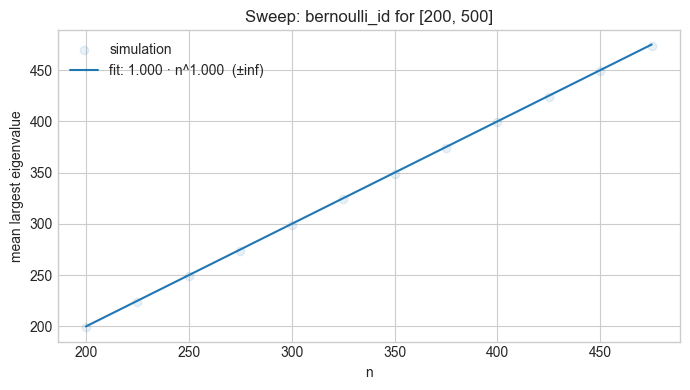

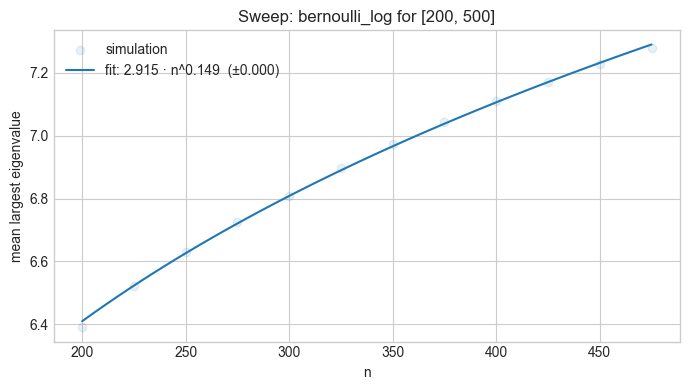

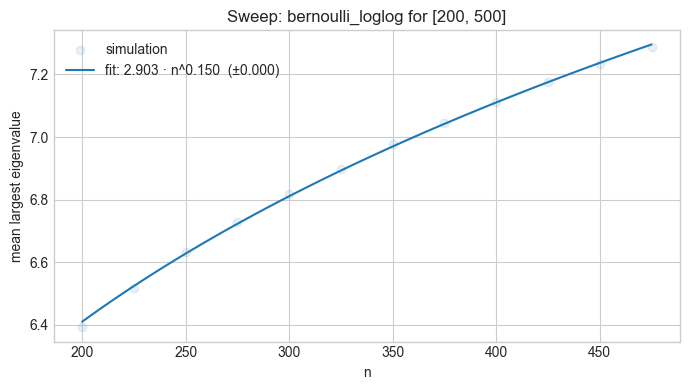

In [22]:
visualize(f"bernoulli_{id.__name__} for [{START}, {END}]", directory="")
visualize(f"bernoulli_{log.__name__} for [{START}, {END}]", directory="")
visualize(f"bernoulli_{loglog.__name__} for [{START}, {END}]", directory="")

plt.show()

In [ ]:
for b in range(1, 10):
    visualize(f"bernoulli_{power_scaling(b/10).__name__} for [{START}, {END}]", directory="bernoulli_power")

plt.show()

In [ ]:
# Assuming that n are big, b does not make impact
for a in range(1, 10):
    visualize(f"bernoulli_{linear_scaling(a/10, 0).__name__} for [{START}, {END}]", directory="bernoulli_linear")

plt.show()

In [ ]:
for p in range(1, 10):
    visualize(f"bernoulli_{constant(p/10).__name__} for [{START}, {END}]", directory="bernoulli_constant")

plt.show()

In [ ]:
visualize(f"normalized_bernoulli_{id.__name__} for [{START}, {END}]", directory="other")
visualize(f"normalized_bernoulli_{log.__name__} for [{START}, {END}]", directory="other")
visualize(f"normalized_bernoulli_{loglog.__name__} for [{START}, {END}]", directory="other")

plt.show()

In [ ]:
for b in range(1, 10):
    visualize(f"normalized_bernoulli_{power_scaling(b/10).__name__} for [{START}, {END}]", directory="normalized_bernoulli_power")

plt.show()

In [ ]:
# Assuming that n are big, b does not make impact
for a in range(1, 10):
    visualize(f"normalized_bernoulli_{linear_scaling(a/10, 0).__name__} for [{START}, {END}]", directory="normalized_bernoulli_linear")

plt.show()

In [ ]:
for p in range(1, 10):
    visualize(f"normalized_bernoulli_{constant(p/10).__name__} for [{START}, {END}]", directory="normalized_bernoulli_constant")

plt.show()

Saved plot to ../img/normal for [200, 500].png
C = 1.8258 ± 0.0023
a = 0.0128 ± 0.0002
Saved plot to ../img/uniform for [200, 500].png
C = 1.0567 ± 0.0013
a = 0.0124 ± 0.0002


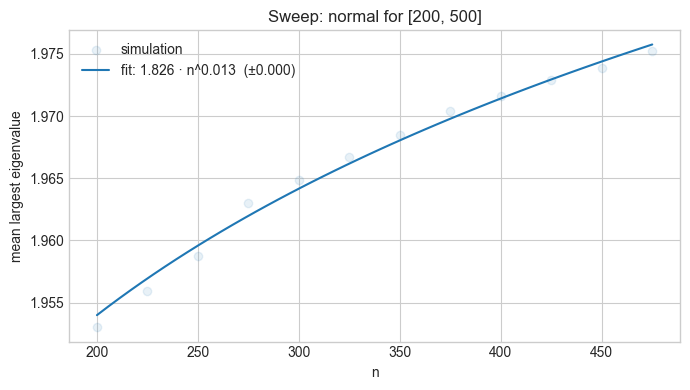

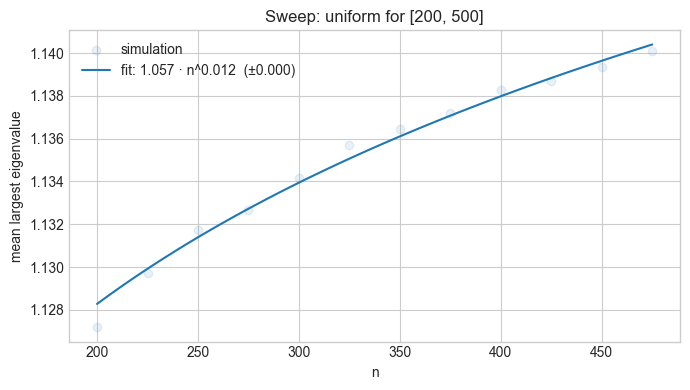

In [23]:
visualize(f"normal for [{START}, {END}]", directory="")
visualize(f"uniform for [{START}, {END}]", directory="")

plt.show()

In [ ]:
START=100
END=300

visualize(f"{power_scaling(5/10).__name__} for [{START}, {END}]")

In [ ]:
START=500
END=700

visualize(f"{power_scaling(5/10).__name__} for [{START}, {END}]")

In [ ]:
START=1000
END=1200

visualize(f"{power_scaling(5/10).__name__} for [{START}, {END}]")

In [ ]:
START=5000
END=5200

visualize(f"{power_scaling(5/10).__name__} for [{START}, {END}]")